# EDA: final processed dataset (data/processed/combined_unique.jsonl)
Volume, category distributions, vocab size for the merged ORACC+CuneiML corpus.

In [5]:
import json
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE))
from src.data_pipeline.prepare_hf_dataset import (
    map_period,
    map_genre,
    map_language,
    map_provenience,
)

PROCESSED = BASE / "data" / "processed"

In [6]:
records = []
with open(PROCESSED / "combined_unique.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

n_tablets = len({r.get("tablet_id") for r in records})
n_signs = sum(len(r.get("signs", [])) for r in records)
print(f"Lines: {len(records):,}")
print(f"Unique tablets: {n_tablets:,}")
print(f"Total sign tokens: {n_signs:,}")
print(f"Avg signs/line: {n_signs / len(records):.1f}")

Lines: 620,405
Unique tablets: 51,737
Total sign tokens: 5,181,007
Avg signs/line: 8.4


In [7]:
with open(PROCESSED / "vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)
print(f"Vocab size (incl. 5 special tokens): {len(vocab):,}")

sign_freq = Counter(s for r in records for s in r.get("signs", []))
print(f"Distinct raw sign strings before min_freq=2 pruning: {len(sign_freq):,}")
print("Top 15 most frequent signs:")
for sign, cnt in sign_freq.most_common(15):
    print(f"  {sign!r}: {cnt:,}")

Vocab size (incl. 5 special tokens): 2,129
Distinct raw sign strings before min_freq=2 pruning: 2,765
Top 15 most frequent signs:
  '𒀀': 212,442
  'x': 166,111
  '𒀭': 126,378
  '𒈾': 123,342
  'X': 115,270
  '𒈠': 104,675
  '𒉌': 100,668
  '𒁹': 91,363
  '𒆠': 81,716
  '𒌑': 76,563
  '𒈬': 68,062
  '𒌓': 66,351
  '𒄿': 65,982
  '𒉡': 65,965
  '𒋗': 64,734


## Category distributions (after substring mapping in `prepare_hf_dataset.py`)
"Unknown" = value present but didn't match any bucket, or field missing -> label -100 (excluded from loss).

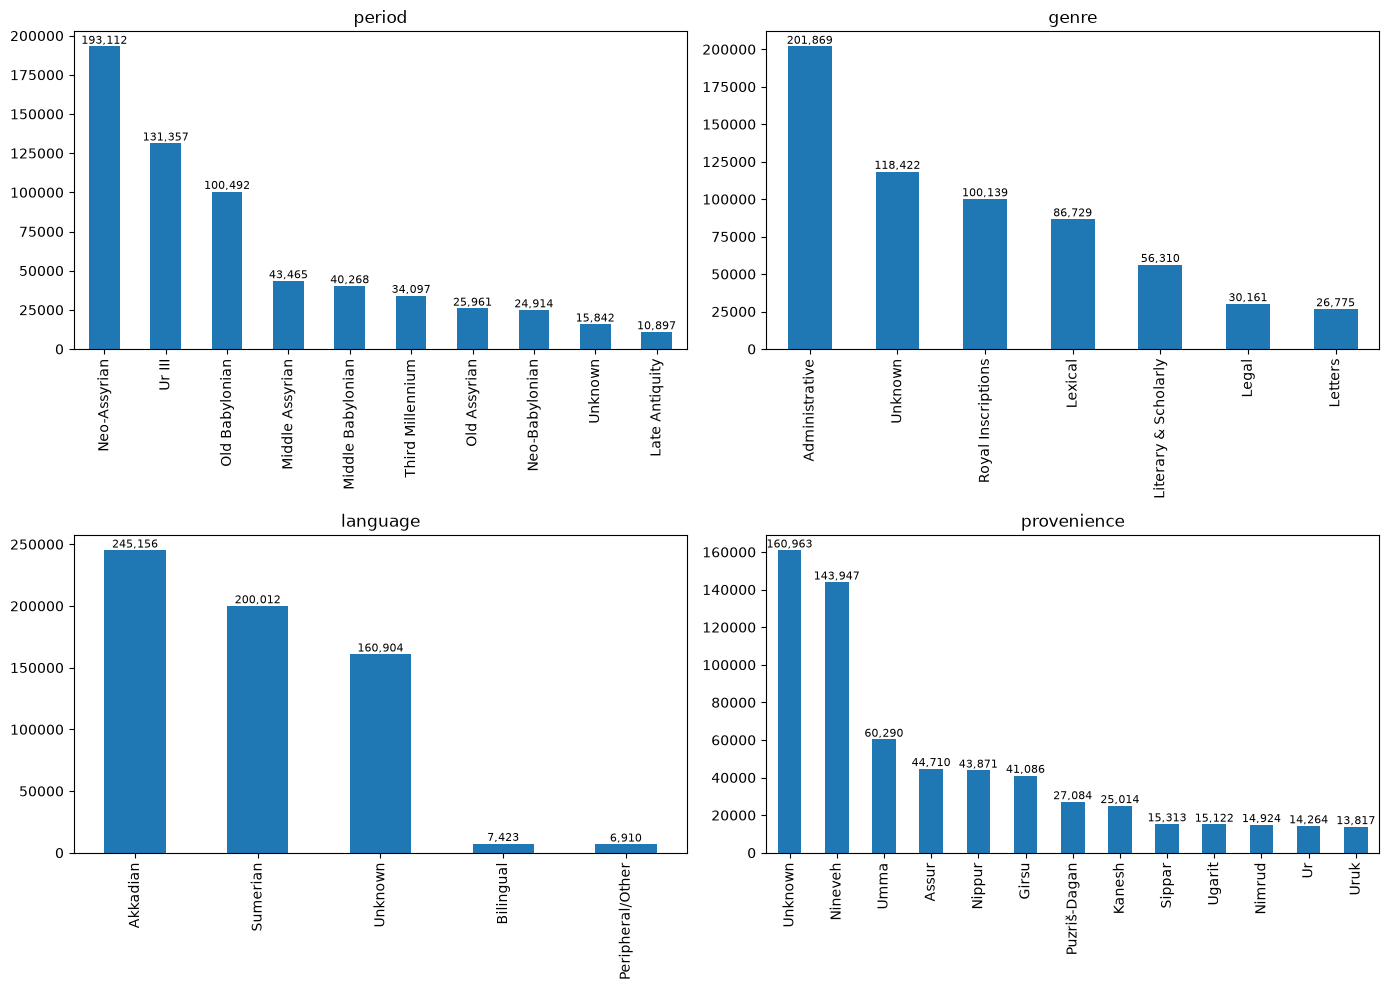

In [8]:
def plot_distribution(field, mapper, ax):
    mapped = Counter(mapper(r.get(field)) for r in records)
    s = pd.Series(mapped).sort_values(ascending=False)
    s.plot(kind="bar", ax=ax)
    ax.set_title(field)
    for i, v in enumerate(s):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    return s


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
period_dist = plot_distribution("period", map_period, axes[0, 0])
genre_dist = plot_distribution("genre", map_genre, axes[0, 1])
language_dist = plot_distribution("language", map_language, axes[1, 0])
provenience_dist = plot_distribution("provenience", map_provenience, axes[1, 1])
plt.tight_layout()
plt.show()

In [9]:
for name, dist in [
    ("period", period_dist),
    ("genre", genre_dist),
    ("language", language_dist),
    ("provenience", provenience_dist),
]:
    known = dist.drop("Unknown", errors="ignore")
    unk = dist.get("Unknown", 0)
    print(
        f"{name}: {unk:,}/{len(records):,} ({unk / len(records):.1%}) Unknown, {len(known)} labeled classes, imbalance ratio max/min = {known.max() / known.min():.0f}x"
    )

period: 15,842/620,405 (2.6%) Unknown, 9 labeled classes, imbalance ratio max/min = 18x
genre: 118,422/620,405 (19.1%) Unknown, 6 labeled classes, imbalance ratio max/min = 8x
language: 160,904/620,405 (25.9%) Unknown, 4 labeled classes, imbalance ratio max/min = 35x
provenience: 160,963/620,405 (25.9%) Unknown, 12 labeled classes, imbalance ratio max/min = 10x
